# Quanto Options pricing under CARMA framework using FFT

## Model parameters definition

In [90]:
#--------------------------------------------------------------------- Imports

import numpy as np
import pandas as pd
from scipy.linalg import expm
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
from dateutil.relativedelta import relativedelta
from scipy.integrate import quad


#------------------------------------------------------------------- Parameters

# CARMA Parameters
sig_X = 0.0399026
b0_X  = 1
b1_X  = 1.41976
b2_X  = 0.0358923
a1_X  = 5.48878
a2_X  = 3.4044
a3_X  = 0.310356

sig_Y = 0.79214262
b0_Y  = 1
b1_Y  = 0.56916278
a1_Y  = 0.90926262
a2_Y  = 0.02497358

# NIG Parameters
mu_X    = -0.044224
delta_X = 0.714666
alpha_X = 0.567515
beta_X  = 0.035207

mu_Y    = 0.05744779
delta_Y = 0.90363048
alpha_Y = 0.47208856 
beta_Y  = -0.02994953

# Coupling parameter
gamma = 0.0227284


#-------------------------------------------------------- Seasonal trend parameters for Y
'''From Gabriel's calibration'''

inputs_Y = {
    "intercept": 10.690454,
    "trend": 0.000009,

    "day_cos_1": -2.773715,
    "day_sin_1": -1.343266,
    "day_cos_2": 0.531358,
    "day_sin_2": 0.000696,
    "day_cos_3": 0.138540,
    "day_sin_3": 0.080035,

    "year_cos_1": -8.946296,
    "year_sin_1": -3.018553,
    "year_cos_2": 0.302592,
    "year_sin_2": 0.767941,
    "year_cos_3": 0.010468,
    "year_sin_3": 0.349874,
}

inter_Y = {
    (0,0): 1.607171, (0,1): -0.312688, (0,2): 0.475547, (0,3): -0.059336, (0,4): -0.078006, (0,5): 0.022845,
    (1,0): 0.756810, (1,1): -0.159529, (1,2): 0.259840, (1,3): -0.126255, (1,4): -0.034853, (1,5): 0.044449,
    (2,0): 0.223024, (2,1): -0.054528, (2,2): -0.334527, (2,3): 0.106636, (2,4): -0.053900, (2,5): -0.004609,
    (3,0): 0.260987, (3,1): 0.050532, (3,2): -0.079633, (3,3): 0.099711, (3,4): -0.034754, (3,5): -0.016093,
    (4,0): -0.384988, (4,1): 0.065902, (4,2): -0.028586, (4,3): 0.012953, (4,4): 0.080202, (4,5): -0.035199,
    (5,0): -0.039476, (5,1): -0.000543, (5,2): -0.019505, (5,3): 0.012494, (5,4): -0.001817, (5,5): -0.029581
}

P_DAY = 24
P_YEAR = 365.25 * 24


#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (3, 3)
AX = np.array([[0,         1,          0],
               [0,         0,          1],
               [-a3_X,    -a2_X,   -a1_X]])

# Noise vector B_X of shape (3, 1)
BX =  np.array([[0   ], [0   ], [sig_X ]])   

# Selection vector c_X of shape (3, 1)
cX = np.array([b0_X, b1_X, b2_X])                          # put b2_X for CARMA(3,2)

# Coupling parameter Γ of shape (3, 1)
Gamma = np.array([[0.0],
                  [0.0],
                  [gamma]])

#---------------------------------------------------------- Matrices for Temperature Y
'''The YUIMA convention holds'''

# Companion matrix A_Y of shape (2, 2)
AY = np.array([[    0,        1  ], 
               [-a2_Y,      -a1_Y]])

# Noise vector B_X of shape (2, 1)
BY = np.array([[ 0 ], [sig_Y]])   

# Selection vector c_X of shape (2, 1)
cY = np.array([b0_Y, b1_Y])     


## Functions definition

In [91]:

#----------------------------------------------- Deterministic function for log prices seasonnal part

file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values"    : seasonal_series.values,            # return a dictionnary of tuples (m, dow, h)
                        "month"  : seasonal_series.index.month,       
                        "dow"    : seasonal_series.index.dayofweek,      # 0=monday ... 6=sunday
                        "hour"   : seasonal_series.index.hour})
          .groupby(["month", "dow", "hour"])["values"]                    # for example, (3, 2, 12) stands for 12h on a wednesday in march
          .mean()                                                        # we take the mean of the series values on the same dayofweek, hour, month
          .to_dict())

def Lambda_S(params):                                            # consistent with Paraschiv's method
    t = params['end_date']
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)
    
#----------------------------------------------- Deterministic function for temperature seasonnal part

def day_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_DAY),
        np.sin(2*np.pi*1*t/P_DAY),
        np.cos(2*np.pi*2*t/P_DAY),
        np.sin(2*np.pi*2*t/P_DAY),
        np.cos(2*np.pi*3*t/P_DAY),
        np.sin(2*np.pi*3*t/P_DAY),
    ])

def year_features(t):
    return np.array([
        np.cos(2*np.pi*1*t/P_YEAR),
        np.sin(2*np.pi*1*t/P_YEAR),
        np.cos(2*np.pi*2*t/P_YEAR),
        np.sin(2*np.pi*2*t/P_YEAR),
        np.cos(2*np.pi*3*t/P_YEAR),
        np.sin(2*np.pi*3*t/P_YEAR),
    ])

    
def Lambda_Y(params):
    t = params['O']
    y = inputs_Y["intercept"] + inputs_Y["trend"] * t

    # day terms
    y += inputs_Y["day_cos_1"] * np.cos(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_sin_1"] * np.sin(2*np.pi*1*t/P_DAY)
    y += inputs_Y["day_cos_2"] * np.cos(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_sin_2"] * np.sin(2*np.pi*2*t/P_DAY)
    y += inputs_Y["day_cos_3"] * np.cos(2*np.pi*3*t/P_DAY)
    y += inputs_Y["day_sin_3"] * np.sin(2*np.pi*3*t/P_DAY)

    # year terms
    y += inputs_Y["year_cos_1"] * np.cos(2*np.pi*1*t/P_YEAR)
    y += inputs_Y["year_sin_1"] * np.sin(2*np.pi*1*t/P_YEAR)
    y += inputs_Y["year_cos_2"] * np.cos(2*np.pi*2*t/P_YEAR)
    y += inputs_Y["year_sin_2"] * np.sin(2*np.pi*2*t/P_YEAR)
    y += inputs_Y["year_cos_3"] * np.cos(2*np.pi*3*t/P_YEAR)
    y += inputs_Y["year_sin_3"] * np.sin(2*np.pi*3*t/P_YEAR)

    # interactions
    d = day_features(t)
    v = year_features(t)
    for (i, j), c in inter_Y.items():
        y += c * d[i] * v[j]

    
    return y


#--------------------------------------------------------------- Discount factor


def discount_factor(r, t):
    r = r / 8760                                 # hourly interest rate for an annual of r percent
    return np.exp(-r*t)

    
#-------------------------------------------------------------- Lévy exponents

    
def psi_X(theta, mu, delta, alpha, beta):
    gamma = np.sqrt(alpha**2 - beta**2)
    return (1j * mu * theta
            + delta * (gamma - np.sqrt(alpha**2 - (beta + 1j*theta)**2)))

def psi_Y(theta, mu, delta, alpha, beta):
    gamma = np.sqrt(alpha**2 - beta**2)
    return (1j * mu * theta
            + delta * (gamma - np.sqrt(alpha**2 - (beta + 1j*theta)**2)))

    
#------------------------------------------------------------- CARMA kernels

    
def kernel_beta_X(s, T, AX, BX, cX):
    return float(BX.flatten() @ expm(AX.T * (T - s)) @ cX)         #flatten transforme BX (3,1) en un vecteur ligne (3,) : ce qui revient a la transposition 
                                                                   #c'est nécessaire ppur la multiplication (3,) * (3,3)

def kernel_beta_Y(s, T, AY, BY, cY):
    return float(BY.flatten() @ expm(AY.T * (T - s)) @ cY)
    
def kernel_gamma_X(s, T, AX, Gamma, cX):
    return float(Gamma.flatten() @ expm(AX.T * (T - s)) @ cX)


#---------------------------------------------------------- Marginal caracteristic function for X

    
def char_function_X(u, T, params, t=0):                                #for the plain energy call
    
    AX, BX, cX = params['AX'], params['BX'], params['cX']
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    Gamma       = params['Gamma']
    mu_X, delta_X, alpha_X, beta_X = params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X']
    mu_Y, delta_Y, alpha_Y, beta_Y = params['mu_Y'], params['delta_Y'], params['alpha_Y'], params['beta_Y']

######## phi_0^X(u)

    def re_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.real(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))
    def im_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.imag(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))

    int_re_X, _ = quad(re_psi_X, t, T, limit=100)
    int_im_X, _ = quad(im_psi_X, t, T, limit=100)

######## phi_0^XY(u,v=0)
    
    def re_psi_Y(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        return np.real(psi_Y(u * g, mu_Y, delta_Y, alpha_Y, beta_Y))
    def im_psi_Y(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        return np.imag(psi_Y(u * g, mu_Y, delta_Y, alpha_Y, beta_Y))

    int_re_Y, _ = quad(re_psi_Y, t, T, limit=100)
    int_im_Y, _ = quad(im_psi_Y, t, T, limit=100)

    return np.exp((int_re_X + int_re_Y) + 1j*(int_im_X + int_im_Y))



#---------------------------------------------------------- Marginal caracteristic function for Y

    
def char_function_Y(v, T, params, t=0):                                #for the plain temperature call
    
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    mu_Y, delta_Y, alpha_Y, beta_Y = params['mu_Y'], params['delta_Y'], params['alpha_Y'], params['beta_Y']

######## phi_0^Y(v)

    def re_psi_Y(s):
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.real(psi_Y(v * b, mu_Y, delta_Y, alpha_Y, beta_Y))
    def im_psi_Y(s):
        b = kernel_beta_Y(s, T, AY, BY, cY)
        return np.imag(psi_Y(v * b, mu_Y, delta_Y, alpha_Y, beta_Y))

    int_re_Y, _ = quad(re_psi_Y, t, T, limit=100)
    int_im_Y, _ = quad(im_psi_Y, t, T, limit=100)

    return np.exp(int_re_Y + 1j*int_im_Y)

    

#---------------------------------------------------------- Joint caracteristic function


def joint_char_function(u, v, T, params, t=0):                                             #Assuming Z_0 = 0, so X_bar and Y_bar vanishe
    
    AX, BX, cX   = params['AX'], params['BX'], params['cX']
    AY, BY, cY   = params['AY'], params['BY'], params['cY']
    Gamma         = params['Gamma']
    mu_X, delta_X, alpha_X, beta_X = params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X']
    mu_Y, delta_Y, alpha_Y, beta_Y = params['mu_Y'], params['delta_Y'], params['alpha_Y'], params['beta_Y']

######## phi_0^X(u)
    
    def re_psi_X(s):                                                        # we split real and imaginary parts because scipy.squad cannot deal with complex integration
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.real(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))

    def im_psi_X(s):
        b = kernel_beta_X(s, T, AX, BX, cX)
        return np.imag(psi_X(u * b, mu_X, delta_X, alpha_X, beta_X))

    int_re_X, _ = quad(re_psi_X, t, T, limit=100)                          # We evaluate these integrals by quadrature using scipy.quad
    int_im_X, _ = quad(im_psi_X, t, T, limit=100)

######## phi_0^XY(u,v)
    
    def re_psi_Y(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        b = kernel_beta_Y(s, T, AY, BY, cY)
        theta = u * g + v * b
        return np.real(psi_Y(theta, mu_Y, delta_Y, alpha_Y, beta_Y))

    def im_psi_Y(s):
        g = kernel_gamma_X(s, T, AX, Gamma, cX)
        b = kernel_beta_Y(s, T, AY, BY, cY)
        theta = u * g + v * b
        return np.imag(psi_Y(theta, mu_Y, delta_Y, alpha_Y, beta_Y))

    int_re_Y, _ = quad(re_psi_Y, t, T, limit=100)                           
    int_im_Y, _ = quad(im_psi_Y, t, T, limit=100)

    phi = np.exp((int_re_X + int_re_Y) + 1j*(int_im_X + int_im_Y))
    return phi


#-------------------------------------------------------- Fourier transform of the payoff functions

'''
Recall that hat_g_{T,alpha}(u,v) = hat_C(u) * hat_h(v), where C stands for the spot price call structure and h for the weather related variable.
'''

# For the call (s - K_S)^+ we are ATM in x = log(K_S + 1000) - Lambda_S(T), so that :
#   hat_C_{alpha1}(u) = (K_S + 1000) e^{-(iu+alpha1)K_S_tilde} / (alpha1 + 1j * u - 1) * (alpha1 + 1j * u)

#for Spot price

def fourier_drifted_call(u, K_S, lam_S, alpha1):
    K_shifted = K_S + 1000                              
    K_bar     = np.log(K_shifted) - lam_S               
    z         = alpha1 + 1j * u                       
    
    return K_shifted * np.exp(-z * K_bar) / ((z - 1) * z)


#for Temperature

def fourier_call(v, K_Y, lam_Y, alpha2):
    K_tilde     = K_Y - lam_Y               
    z         = alpha2 + 1j * v                       
    
    return np.exp(-z * K_tilde) / (z**2)


#see my notes for details

def fourier_h(v, K_Y, lam_Y, alpha2, h_type):
    
    K_tilde = K_Y - lam_Y   

    if h_type == 'indicator':                                           # with alpha2 > 0
        return np.exp(-(alpha2 + 1j*v) * K_tilde) / (alpha2 + 1j*v) 
    elif h_type == 'none':
        return 1
    elif h_type == 'call':                                              # with alpha2 > 0
        denom = (1j * v + alpha2)**2
        return np.exp(-(alpha2 + 1j*v) * K_tilde) / denom

    elif h_type == 'put':                                               # with alpha2 < 0
        denom = (1j * v + alpha2)**2
        return np.exp(-(alpha2 + 1j*v) * K_tilde) / denom





## Plain energy call pricing

#### FFT parameters choice

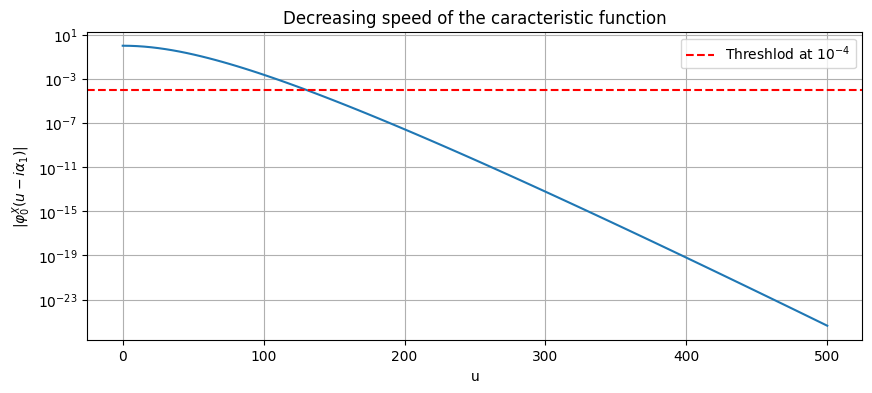

U_max needed : 131.31


In [92]:
#------------------------------------------------------------ Parameters dictionnary

start_date = pd.Timestamp("2026-05-12 16:00:00")
end_date = pd.Timestamp("2026-06-12 19:00:00")
origin_date = pd.Timestamp("2026-01-01 00:00:00")      # Date corresponding to t=0 in Lambda_Y(t)

T = (end_date - start_date).total_seconds() / 3600     # Distance from maturity (hour)
O = (end_date - origin_date).total_seconds() / 3600    # Distance from origin (hour)


params = {'AX': AX, 'BX': BX, 'cX': cX, 'Gamma': Gamma,
          'AY': AY, 'BY': BY, 'cY': cY,
          'mu_X': mu_X, 'delta_X': delta_X, 'alpha_X': alpha_X, 'beta_X': beta_X,
          'mu_Y': mu_Y, 'delta_Y': delta_Y, 'alpha_Y': alpha_Y, 'beta_Y': beta_Y,
          
          'start_date': start_date,
          'end_date': end_date,
          'origin_date' : origin_date,   
          'T' : T,                      
          'O' : O,                      
          
          'N' : 100_000,
          'dt' : 1,
          'n_steps': T,                            # because dt is fixed to 1
          'r' : 0,
          'K_S' : 130,
          'K_Y' : 15,
          'alpha1' : 1.5,
          'alpha2' : 1.5,
          'eta1' : 0.05,
          'eta2' : 0.05,
          'n_s': 3000,
          'M' : 6000}


#--------------------------------------------------------- Discretization parameters choice


alpha1 = params['alpha1']
u_range = np.linspace(0, 500, 100)
phi_values = np.array([abs(char_function_X(u - 1j*alpha1, T, params)) for u in u_range])

plt.figure(figsize=(10, 4))
plt.semilogy(u_range, phi_values)
plt.axhline(1e-4, color='r', linestyle='--', label='Threshlod at $10^{-4}$')
plt.xlabel('u')
plt.ylabel(r'|$\varphi_0^X(u - i\alpha_1)$|')
plt.title('Decreasing speed of the caracteristic function')
plt.legend()
plt.grid(True)
plt.show()

# U_max is the minimal needed value to make the quadrature error small enough
U_max = u_range[np.where(phi_values < 1e-4)[0][0]]
print(f"U_max needed : {U_max:.2f}")

#### Test for damping parameters and grid edges

In [25]:
#---------------------------------------------------- phi_0 should be negligible one the grid edges

M, T, eta1 = params['M'], params['T'], params['eta1']
u_max = (M//2 - 1) * eta1
u_min = - (M//2) * eta1
phi_u_max = abs(joint_char_function(u_max - 1j*alpha1, 0, T, params))
phi_u_min = abs(joint_char_function(u_min - 1j*alpha1, 0, T, params))

print(f"|phi_0| on max edge : {phi_u_max:.2e}")  # should be << 1
print(f"|phi_0| on min edge : {phi_u_min:.2e}")  # should be << 1


#------------------------------------------------------ Checking of the damping parameter

def check_damping(alpha1, params, T):
    
    AX, BX, cX = params['AX'], params['BX'], params['cX']
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    Gamma       = params['Gamma']
    alpha_X, beta_X = params['alpha_X'], params['beta_X']
    alpha_Y, beta_Y = params['alpha_Y'], params['beta_Y']
    n_s = params['n_s']
    
    s_grid = np.linspace(0, T, n_s)

    kernel_betaX  = np.array([kernel_beta_X(s, T, AX, BX, cX)     for s in s_grid])

    # NIG constraint on alpha1 : |beta_X + alpha1 * bX(s)| < alpha_X
    nig_constraint = np.all(np.abs(beta_X + alpha1 * kernel_betaX) < alpha_X)

    # Call constraint on alpha1 
    call_constraint = alpha1 > 1

    print(f"Call constraint  (alpha1 > 1) : {'Satisfied' if call_constraint else 'Rejected'}")
    print(f"NIG constraint  (|beta_X + alpha1 * kernel_betaX| < alpha_X) : {'Satisfied' if nig_constraint  else 'Rejected'}")
    print(f"max |beta_X + alpha1 * kernel_betaX| = {np.max(np.abs(beta_X + alpha1 * kernel_betaX)):.4f}  (should be  < {alpha_X})")

    return call_constraint  and nig_constraint


check_damping(alpha1=1.5, params=params, T=params['T'])


|phi_0| au bord en u : 1.09e-05
|phi_0| au bord en v : 1.08e-05
Call constraint  (alpha1 > 1) : Satisfied
NIG constraint  (|beta_X + alpha1 * kernel_betaX| < alpha_X) : Satisfied
max |beta_X + alpha1 * kernel_betaX| = 0.0526  (should be  < 0.567515)


np.True_

#### Pricing

In [93]:
def energy_call_FFT_price(params):

    T     = params['T']
    K_S   = params['K_S']
    r     = params['r']
    lam_S = Lambda_S(params)
    eta_1, alpha1 = params['eta1'], params['alpha1']
    M, n_s = params['M'], params['n_s']
    
    u   = (-M//2 + np.arange(M)) * eta1           # (M,)

    w      = np.full(M, eta1)
    w[0]  *= 0.5
    w[-1] *= 0.5

    
    s_grid = np.linspace(0, T, n_s)

    AX, BX, cX = params['AX'], params['BX'], params['cX']
    AY, BY, cY = params['AY'], params['BY'], params['cY']
    Gamma       = params['Gamma']

    bX = np.array([kernel_beta_X(s, T, AX, BX, cX)       for s in s_grid])  # (n_s,)
    gX = np.array([kernel_gamma_X(s, T, AX, Gamma, cX)    for s in s_grid])  # (n_s,)

    arg_X = np.outer(u - 1j*alpha1, bX)   # (M, n_s)
    arg_Y = np.outer(u - 1j*alpha1, gX)   # (M, n_s)  v=0

    psi_X_values = psi_X(arg_X, params['mu_X'], params['delta_X'], params['alpha_X'], params['beta_X'])   # (M, n_s)

    psi_Y_values = psi_Y(arg_Y, params['mu_Y'], params['delta_Y'], params['alpha_Y'], params['beta_Y'])   # (M, n_s)

    phi     = np.exp(np.trapezoid(psi_X_values + psi_Y_values, s_grid, axis=1))     # (M,)

    C_hat = fourier_drifted_call(u, K_S, lam_S, alpha1)                 # (M,)


    integral = np.sum(w * C_hat * phi)

    return (np.exp(-r * T) / (2*np.pi) * integral).real


FFT_price = energy_call_FFT_price(params)

print(f"FFT price : {FFT_price:.4f}")

FFT price : 21.5966


## Plain temperature call pricing

#### FFT parameters choice

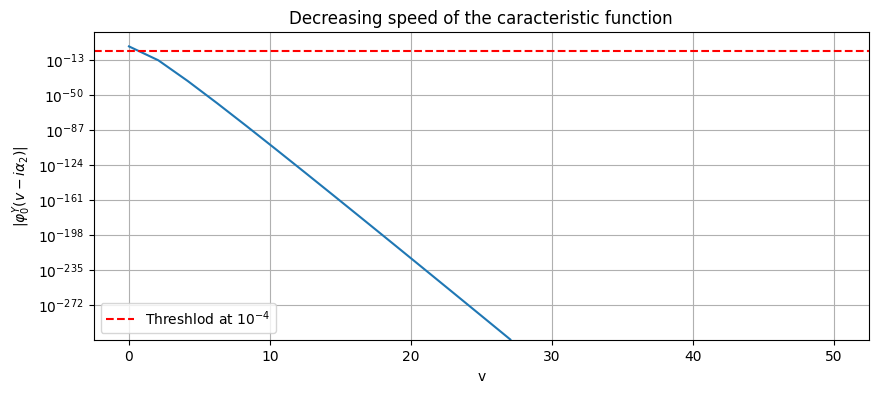

V_max needed : 2.08


In [85]:
#------------------------------------------------------------ Parameters dictionnary

start_date = pd.Timestamp("2026-05-12 16:00:00")
end_date = pd.Timestamp("2026-06-12 19:00:00")
origin_date = pd.Timestamp("2026-01-01 00:00:00")      # Date corresponding to t=0 in Lambda_Y(t)

T = (end_date - start_date).total_seconds() / 3600     # Distance from maturity (hour)
O = (end_date - origin_date).total_seconds() / 3600    # Distance from origin (hour)


params = {'AX': AX, 'BX': BX, 'cX': cX, 'Gamma': Gamma,
          'AY': AY, 'BY': BY, 'cY': cY,
          'mu_X': mu_X, 'delta_X': delta_X, 'alpha_X': alpha_X, 'beta_X': beta_X,
          'mu_Y': mu_Y, 'delta_Y': delta_Y, 'alpha_Y': alpha_Y, 'beta_Y': beta_Y,
          
          'start_date': start_date,
          'end_date': end_date,
          'origin_date' : origin_date,   
          'T' : T,                      
          'O' : O,                      
          
          'N' : 100_000,
          'dt' : 1,
          'n_steps': T,                            # because dt is fixed to 1
          'r' : 0,
          'K_S' : 130,
          'K_Y' : 15,
          'alpha1' : 1.5,
          'alpha2' : 0.4,
          'eta1' : 0.05,
          'eta2' : 0.05,
          'n_s': 3000,
          'M' : 6000}


#--------------------------------------------------------- Discretization parameters choice


alpha2 = params['alpha2']
v_range = np.linspace(0, 50, 25)
phi_values = np.array([abs(char_function_Y(v - 1j*alpha2, T, params)) for v in v_range])

plt.figure(figsize=(10, 4))
plt.semilogy(v_range, phi_values)
plt.axhline(1e-4, color='r', linestyle='--', label='Threshlod at $10^{-4}$')
plt.xlabel('v')
plt.ylabel(r'|$\varphi_0^Y(v - i\alpha_2)$|')
plt.title('Decreasing speed of the caracteristic function')
plt.legend()
plt.grid(True)
plt.show()

# U_max is the minimal needed value to make the quadrature error small enough
V_max = v_range[np.where(phi_values < 1e-4)[0][0]]
print(f"V_max needed : {V_max:.2f}")

#### Pricing

In [86]:
def temperature_call_FFT_price(params):

    T     = params['T']
    K_Y   = params['K_Y']
    r     = params['r']
    lam_Y = Lambda_Y(params)
    eta2, alpha2 = params['eta2'], params['alpha2']
    M, n_s = params['M'], params['n_s']
    
    v   = (-M//2 + np.arange(M)) * eta2           # (M,)

    w      = np.full(M, eta2)
    w[0]  *= 0.5
    w[-1] *= 0.5

    s_grid = np.linspace(0, T, n_s)

    AY, BY, cY = params['AY'], params['BY'], params['cY']

    bY     = np.array([kernel_beta_Y(s, T, AY, BY, cY) for s in s_grid])

    arg_Y = np.outer(v - 1j*alpha2, bY)   # (M, n_s)

    psi_Y_values = psi_Y(arg_Y, params['mu_Y'], params['delta_Y'], params['alpha_Y'], params['beta_Y'])   # (M, n_s)

    phi     = np.exp(np.trapezoid(psi_Y_values, s_grid, axis=1))     # (M,)

    C_hat = fourier_call(v, K_Y, lam_Y, alpha2)                 # (M,)

    integral = np.sum(w * C_hat * phi)

    return (np.exp(-r * T) / (2*np.pi) * integral).real


FFT_price = temperature_call_FFT_price(params)

print(f"FFT price : {FFT_price:.4f}")

FFT price : 4.5104
